In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_6_channel = pd.read_csv("df_6_channel.csv")

df_6_channel["date"] = pd.to_datetime(df_6_channel["date"])

# Đảm bảo không chia cho 0
df_6_channel["conversion_rate"] = np.where(
    df_6_channel["sessions"] > 0,
    df_6_channel["num_orders"] / df_6_channel["sessions"],
    0
)

df_6_channel["orders_per_1000_sessions"] = df_6_channel["conversion_rate"] * 1000

df_6_channel.head()

,date,traffic_source,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,num_orders,num_customers,conversion_rate,orders_per_1000_sessions
0,2013-01-01,organic_search,9760,7253,39093,0.00514,102.9,80.0,80.0,0.008197,8.196721
1,2013-01-02,organic_search,10456,8151,47611,0.00406,120.5,18.0,18.0,0.001721,1.721500
2,2013-01-03,direct,10076,7458,36963,0.00401,263.6,4.0,4.0,0.000397,0.396983
3,2013-01-04,direct,9973,8063,53078,0.00562,151.8,5.0,5.0,0.000501,0.501354
4,2013-01-05,referral,10223,7882,36790,0.00525,168.6,8.0,8.0,0.000783,0.782549


In [2]:
channel_perf = df_6_channel.groupby("traffic_source").agg(
    total_sessions=("sessions", "sum"),
    total_unique_visitors=("unique_visitors", "sum"),
    total_page_views=("page_views", "sum"),
    avg_bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean"),
    total_orders=("num_orders", "sum"),
    total_customers=("num_customers", "sum")
).reset_index()

channel_perf["conversion_rate"] = channel_perf["total_orders"] / channel_perf["total_sessions"]
channel_perf["orders_per_1000_sessions"] = channel_perf["conversion_rate"] * 1000
channel_perf["traffic_share"] = channel_perf["total_sessions"] / channel_perf["total_sessions"].sum()
channel_perf["order_share"] = channel_perf["total_orders"] / channel_perf["total_orders"].sum()

channel_perf = channel_perf.sort_values("conversion_rate", ascending=False)

channel_perf

,traffic_source,total_sessions,total_unique_visitors,total_page_views,avg_bounce_rate,avg_session_duration_sec,total_orders,total_customers,conversion_rate,orders_per_1000_sessions,traffic_share,order_share
2,organic_search,27196976,20625107,117606452,0.004504,211.153945,50534.0,50427.0,0.001858,1.858074,0.297389,0.415624
3,paid_search,19598271,14922386,85079551,0.004478,209.362117,29203.0,29147.0,0.001490,1.490080,0.214300,0.240184
5,social_media,15816226,12048065,68072140,0.004476,210.290190,21999.0,21960.0,0.001391,1.390913,0.172945,0.180934
1,email_campaign,12792670,9700462,55477636,0.004458,213.220594,10135.0,10127.0,0.000792,0.792251,0.139883,0.083357
4,referral,9476845,7220019,41655659,0.004499,207.558667,6197.0,6194.0,0.000654,0.653910,0.103626,0.050968
0,direct,6571549,4986650,28771362,0.004511,207.678195,3518.0,3516.0,0.000535,0.535338,0.071857,0.028934


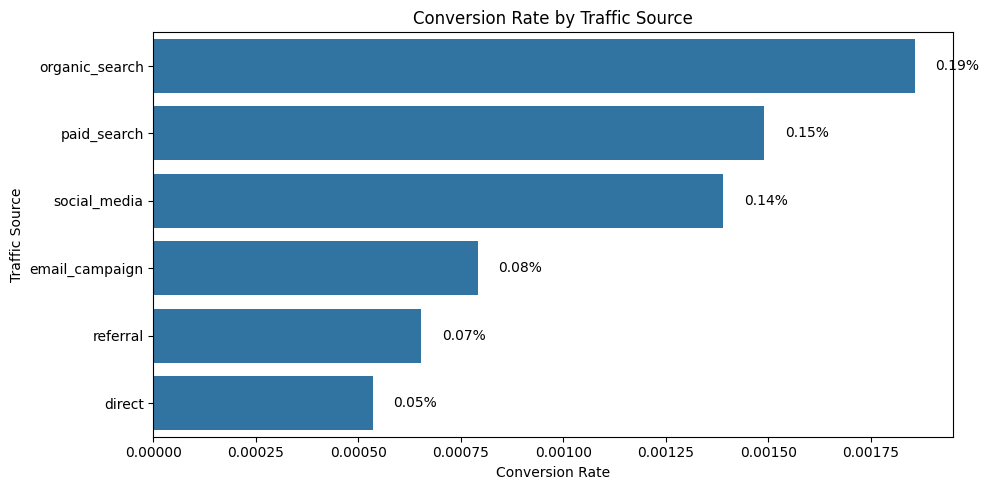

In [3]:
plt.figure(figsize=(10, 5))

plot_data = channel_perf.sort_values("conversion_rate", ascending=False)

sns.barplot(
    data=plot_data,
    x="conversion_rate",
    y="traffic_source"
)

plt.title("Conversion Rate by Traffic Source")
plt.xlabel("Conversion Rate")
plt.ylabel("Traffic Source")

for i, value in enumerate(plot_data["conversion_rate"]):
    plt.text(
        value + 0.00005,
        i,
        f"{value*100:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

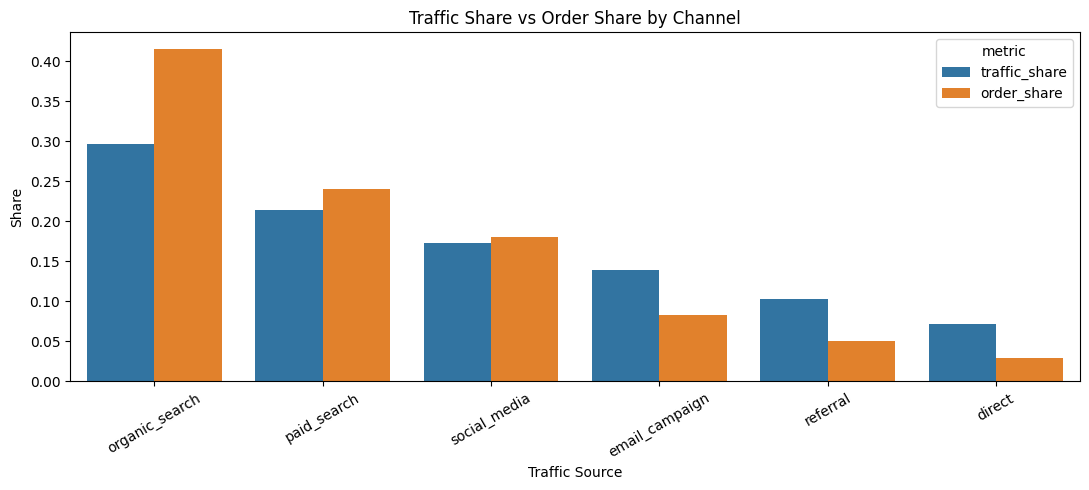

In [4]:
share_data = channel_perf[["traffic_source", "traffic_share", "order_share"]].copy()

share_long = share_data.melt(
    id_vars="traffic_source",
    value_vars=["traffic_share", "order_share"],
    var_name="metric",
    value_name="share"
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=share_long,
    x="traffic_source",
    y="share",
    hue="metric"
)

plt.title("Traffic Share vs Order Share by Channel")
plt.xlabel("Traffic Source")
plt.ylabel("Share")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

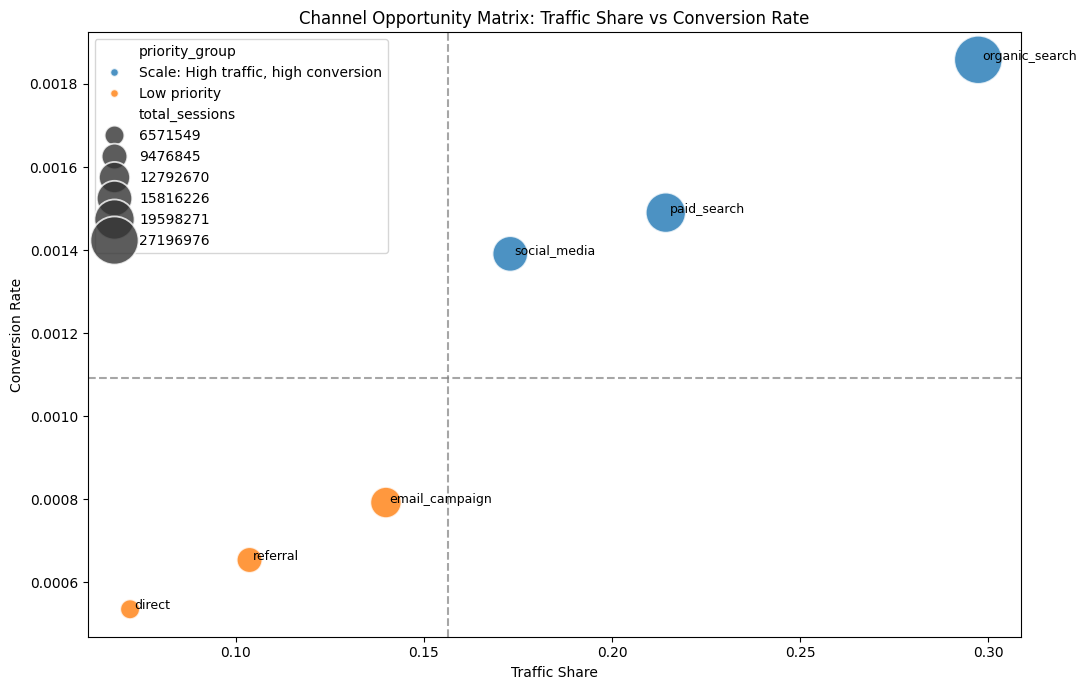

,traffic_source,total_sessions,total_unique_visitors,total_page_views,avg_bounce_rate,avg_session_duration_sec,total_orders,total_customers,conversion_rate,orders_per_1000_sessions,traffic_share,order_share,priority_group
1,email_campaign,12792670,9700462,55477636,0.004458,213.220594,10135.0,10127.0,0.000792,0.792251,0.139883,0.083357,Low priority
4,referral,9476845,7220019,41655659,0.004499,207.558667,6197.0,6194.0,0.000654,0.653910,0.103626,0.050968,Low priority
0,direct,6571549,4986650,28771362,0.004511,207.678195,3518.0,3516.0,0.000535,0.535338,0.071857,0.028934,Low priority
2,organic_search,27196976,20625107,117606452,0.004504,211.153945,50534.0,50427.0,0.001858,1.858074,0.297389,0.415624,"Scale: High traffic, high conversion"
3,paid_search,19598271,14922386,85079551,0.004478,209.362117,29203.0,29147.0,0.001490,1.490080,0.214300,0.240184,"Scale: High traffic, high conversion"
5,social_media,15816226,12048065,68072140,0.004476,210.290190,21999.0,21960.0,0.001391,1.390913,0.172945,0.180934,"Scale: High traffic, high conversion"


In [5]:
channel_matrix = channel_perf.copy()

traffic_median = channel_matrix["traffic_share"].median()
conv_median = channel_matrix["conversion_rate"].median()

def classify_channel(row):
    if row["traffic_share"] >= traffic_median and row["conversion_rate"] >= conv_median:
        return "Scale: High traffic, high conversion"
    elif row["traffic_share"] >= traffic_median and row["conversion_rate"] < conv_median:
        return "Fix: High traffic, low conversion"
    elif row["traffic_share"] < traffic_median and row["conversion_rate"] >= conv_median:
        return "Test growth: Low traffic, high conversion"
    else:
        return "Low priority"

channel_matrix["priority_group"] = channel_matrix.apply(classify_channel, axis=1)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=channel_matrix,
    x="traffic_share",
    y="conversion_rate",
    size="total_sessions",
    hue="priority_group",
    sizes=(200, 1200),
    alpha=0.8
)

plt.axvline(
    traffic_median,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label="Median Traffic Share"
)

plt.axhline(
    conv_median,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label="Median Conversion Rate"
)

for _, row in channel_matrix.iterrows():
    plt.text(
        row["traffic_share"] + 0.001,
        row["conversion_rate"],
        row["traffic_source"],
        fontsize=9
    )

plt.title("Channel Opportunity Matrix: Traffic Share vs Conversion Rate")
plt.xlabel("Traffic Share")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

channel_matrix.sort_values(
    ["priority_group", "traffic_share"],
    ascending=[True, False]
)

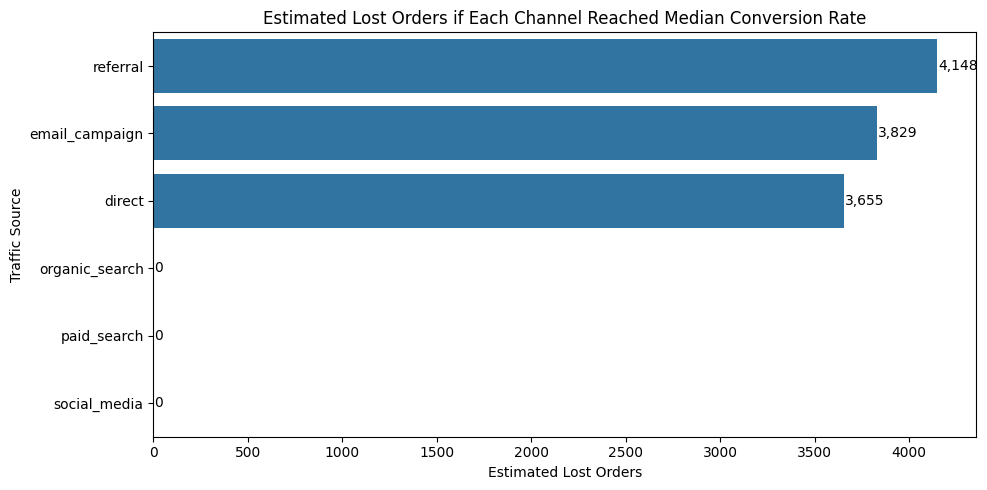

,traffic_source,total_sessions,total_orders,conversion_rate,expected_orders_at_benchmark,lost_orders_proxy,priority_group
4,referral,9476845,6197.0,0.000654,10344.753036,4147.753036,Low priority
1,email_campaign,12792670,10135.0,0.000792,13964.247787,3829.247787,Low priority
0,direct,6571549,3518.0,0.000535,7173.384335,3655.384335,Low priority
2,organic_search,27196976,50534.0,0.001858,29687.728357,0.000000,"Scale: High traffic, high conversion"
3,paid_search,19598271,29203.0,0.001490,21393.119063,0.000000,"Scale: High traffic, high conversion"
5,social_media,15816226,21999.0,0.001391,17264.706970,0.000000,"Scale: High traffic, high conversion"


In [6]:
benchmark_cr = channel_matrix["conversion_rate"].median()

channel_matrix["expected_orders_at_benchmark"] = channel_matrix["total_sessions"] * benchmark_cr

channel_matrix["lost_orders_proxy"] = (
    channel_matrix["expected_orders_at_benchmark"] - channel_matrix["total_orders"]
).clip(lower=0)

lost_orders = channel_matrix.sort_values("lost_orders_proxy", ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=lost_orders,
    x="lost_orders_proxy",
    y="traffic_source"
)

plt.title("Estimated Lost Orders if Each Channel Reached Median Conversion Rate")
plt.xlabel("Estimated Lost Orders")
plt.ylabel("Traffic Source")

for i, value in enumerate(lost_orders["lost_orders_proxy"]):
    plt.text(
        value + 5,
        i,
        f"{value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

lost_orders[[
    "traffic_source",
    "total_sessions",
    "total_orders",
    "conversion_rate",
    "expected_orders_at_benchmark",
    "lost_orders_proxy",
    "priority_group"
]]

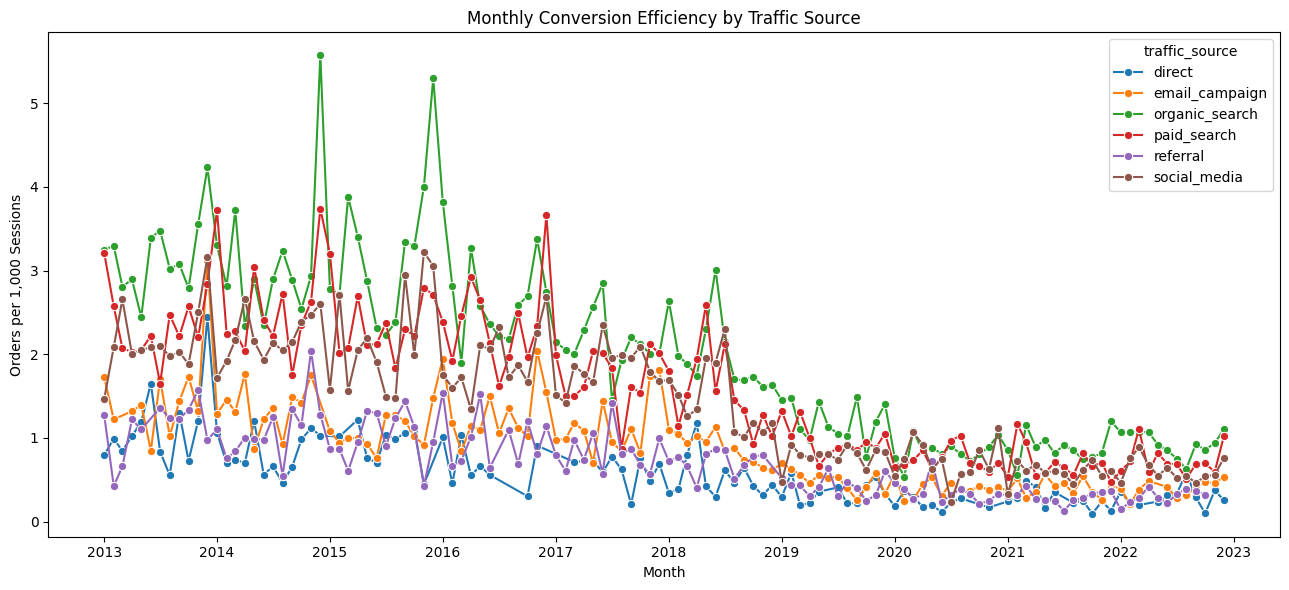

In [8]:
monthly_channel = df_6_channel.copy()
monthly_channel["month"] = monthly_channel["date"].dt.to_period("M").dt.to_timestamp()

monthly_channel = monthly_channel.groupby(["month", "traffic_source"]).agg(
    sessions=("sessions", "sum"),
    orders=("num_orders", "sum")
).reset_index()

monthly_channel["conversion_rate"] = monthly_channel["orders"] / monthly_channel["sessions"]
monthly_channel["orders_per_1000_sessions"] = monthly_channel["conversion_rate"] * 1000

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=monthly_channel,
    x="month",
    y="orders_per_1000_sessions",
    hue="traffic_source",
    marker="o"
)

plt.title("Monthly Conversion Efficiency by Traffic Source")
plt.xlabel("Month")
plt.ylabel("Orders per 1,000 Sessions")
plt.tight_layout()
plt.show()

/tmp/ipykernel_19746/99429178.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


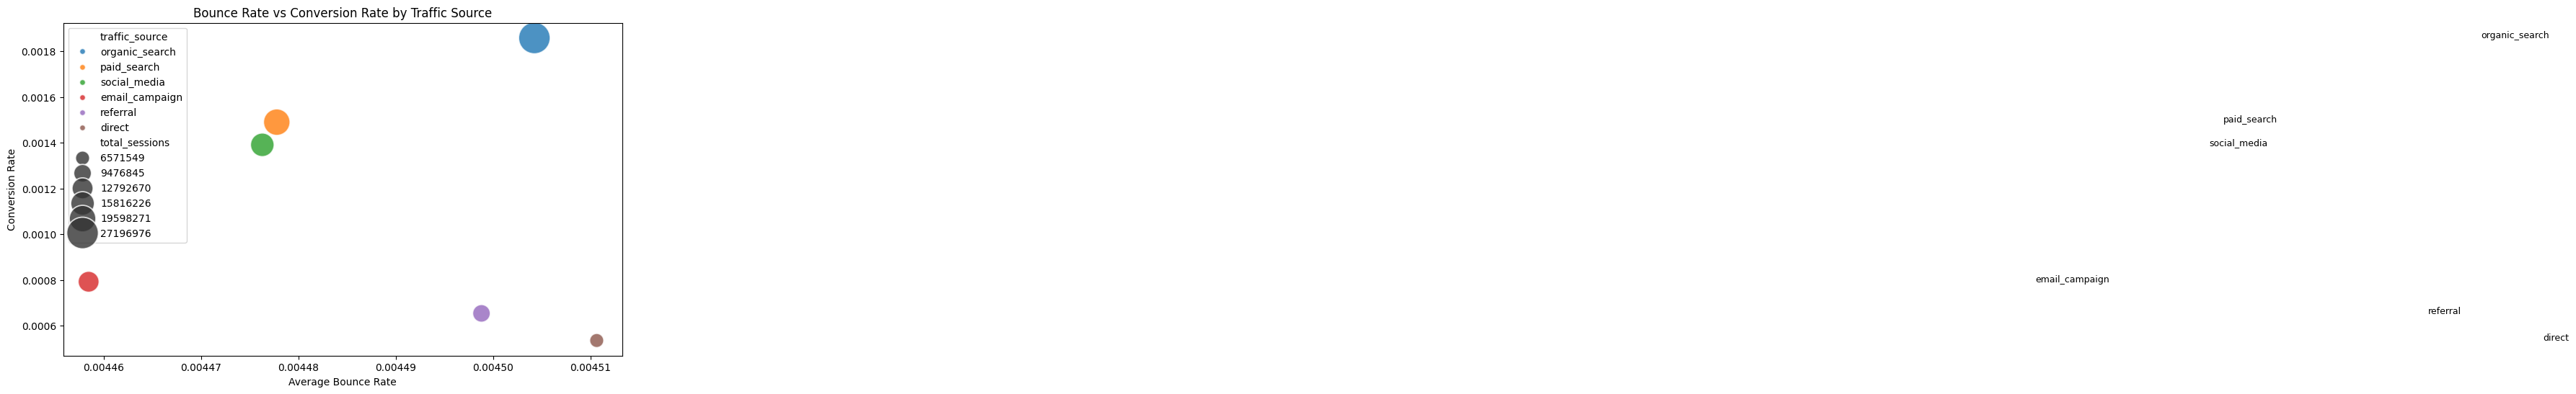

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=channel_matrix,
    x="avg_bounce_rate",
    y="conversion_rate",
    size="total_sessions",
    hue="traffic_source",
    sizes=(200, 1000),
    alpha=0.8
)

for _, row in channel_matrix.iterrows():
    plt.text(
        row["avg_bounce_rate"] + 0.0002,
        row["conversion_rate"],
        row["traffic_source"],
        fontsize=9
    )

plt.title("Bounce Rate vs Conversion Rate by Traffic Source")
plt.xlabel("Average Bounce Rate")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

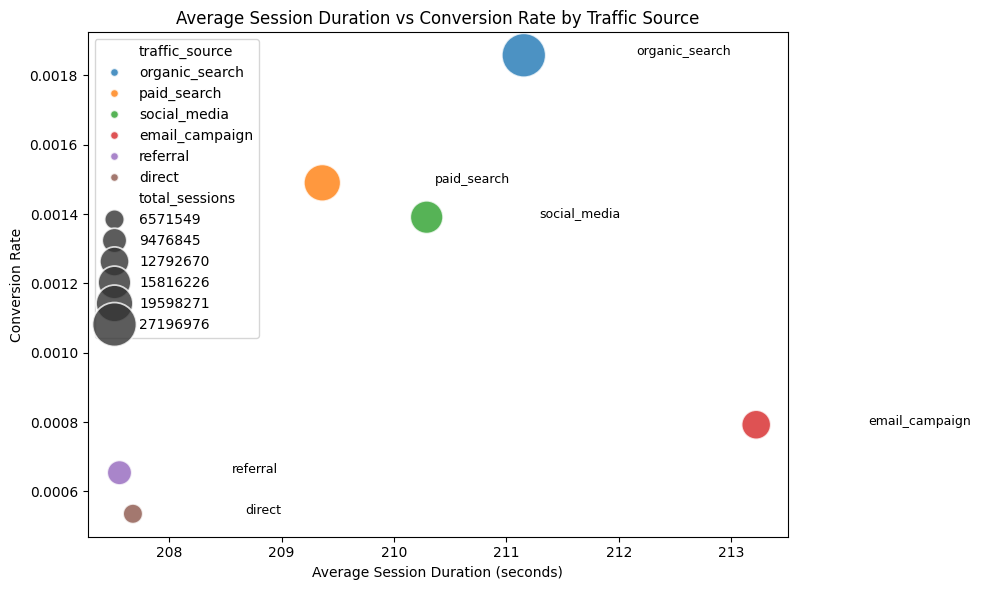

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=channel_matrix,
    x="avg_session_duration_sec",
    y="conversion_rate",
    size="total_sessions",
    hue="traffic_source",
    sizes=(200, 1000),
    alpha=0.8
)

for _, row in channel_matrix.iterrows():
    plt.text(
        row["avg_session_duration_sec"] + 1,
        row["conversion_rate"],
        row["traffic_source"],
        fontsize=9
    )

plt.title("Average Session Duration vs Conversion Rate by Traffic Source")
plt.xlabel("Average Session Duration (seconds)")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

In [11]:
best_channel = channel_matrix.sort_values("conversion_rate", ascending=False).iloc[0]
worst_channel = channel_matrix.sort_values("conversion_rate", ascending=True).iloc[0]
largest_traffic_channel = channel_matrix.sort_values("traffic_share", ascending=False).iloc[0]
largest_lost_channel = channel_matrix.sort_values("lost_orders_proxy", ascending=False).iloc[0]

print("Best converting channel:")
print(f"- {best_channel['traffic_source']} with conversion rate {best_channel['conversion_rate']*100:.2f}%")

print("\nWorst converting channel:")
print(f"- {worst_channel['traffic_source']} with conversion rate {worst_channel['conversion_rate']*100:.2f}%")

print("\nLargest traffic channel:")
print(f"- {largest_traffic_channel['traffic_source']} with traffic share {largest_traffic_channel['traffic_share']*100:.2f}%")

print("\nLargest estimated lost-order opportunity:")
print(f"- {largest_lost_channel['traffic_source']} with estimated lost orders of {largest_lost_channel['lost_orders_proxy']:,.0f}")

Best converting channel:
- organic_search with conversion rate 0.19%

Worst converting channel:
- direct with conversion rate 0.05%

Largest traffic channel:
- organic_search with traffic share 29.74%

Largest estimated lost-order opportunity:
- referral with estimated lost orders of 4,148


In [12]:
recommendation_table = channel_matrix.copy()

def recommendation(row):
    if row["priority_group"] == "Scale: High traffic, high conversion":
        return "Scale marketing budget and maintain current landing page strategy."
    elif row["priority_group"] == "Fix: High traffic, low conversion":
        return "Prioritize landing page optimization, checkout simplification, and campaign-message alignment."
    elif row["priority_group"] == "Test growth: Low traffic, high conversion":
        return "Run controlled budget expansion tests because this channel converts well but has limited traffic."
    else:
        return "Keep monitoring, but do not prioritize major investment."

recommendation_table["recommendation"] = recommendation_table.apply(recommendation, axis=1)

recommendation_table = recommendation_table[[
    "traffic_source",
    "total_sessions",
    "total_orders",
    "traffic_share",
    "order_share",
    "conversion_rate",
    "orders_per_1000_sessions",
    "lost_orders_proxy",
    "priority_group",
    "recommendation"
]].sort_values("lost_orders_proxy", ascending=False)

recommendation_table

,traffic_source,total_sessions,total_orders,traffic_share,order_share,conversion_rate,orders_per_1000_sessions,lost_orders_proxy,priority_group,recommendation
4,referral,9476845,6197.0,0.103626,0.050968,0.000654,0.653910,4147.753036,Low priority,"Keep monitoring, but do not prioritize major i..."
1,email_campaign,12792670,10135.0,0.139883,0.083357,0.000792,0.792251,3829.247787,Low priority,"Keep monitoring, but do not prioritize major i..."
0,direct,6571549,3518.0,0.071857,0.028934,0.000535,0.535338,3655.384335,Low priority,"Keep monitoring, but do not prioritize major i..."
2,organic_search,27196976,50534.0,0.297389,0.415624,0.001858,1.858074,0.000000,"Scale: High traffic, high conversion",Scale marketing budget and maintain current la...
3,paid_search,19598271,29203.0,0.214300,0.240184,0.001490,1.490080,0.000000,"Scale: High traffic, high conversion",Scale marketing budget and maintain current la...
5,social_media,15816226,21999.0,0.172945,0.180934,0.001391,1.390913,0.000000,"Scale: High traffic, high conversion",Scale marketing budget and maintain current la...


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_6_daily = pd.read_csv("df_6_daily.csv")

df_6_daily["date"] = pd.to_datetime(df_6_daily["date"])

# Sort lại theo thời gian
df_6_daily = df_6_daily.sort_values("date").reset_index(drop=True)

# Tính lại conversion cho chắc
df_6_daily["conversion_rate"] = np.where(
    df_6_daily["sessions"] > 0,
    df_6_daily["num_orders"] / df_6_daily["sessions"],
    0
)

df_6_daily["orders_per_1000_sessions"] = df_6_daily["conversion_rate"] * 1000

# Time features
df_6_daily["year"] = df_6_daily["date"].dt.year
df_6_daily["month"] = df_6_daily["date"].dt.month
df_6_daily["month_name"] = df_6_daily["date"].dt.month_name()
df_6_daily["year_month"] = df_6_daily["date"].dt.to_period("M").dt.to_timestamp()
df_6_daily["day_of_week"] = df_6_daily["date"].dt.day_name()
df_6_daily["is_weekend"] = df_6_daily["date"].dt.dayofweek.isin([5, 6]).astype(int)

df_6_daily.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,num_orders,num_customers,conversion_rate,orders_per_1000_sessions,year,month,month_name,year_month,day_of_week,is_weekend
0,2013-01-01,9760,7253,39093,0.00514,102.9,288,283,0.029508,29.508197,2013,1,January,2013-01-01,Tuesday,0
1,2013-01-02,10456,8151,47611,0.00406,120.5,47,47,0.004495,4.495027,2013,1,January,2013-01-01,Wednesday,0
2,2013-01-03,10076,7458,36963,0.00401,263.6,81,80,0.008039,8.038904,2013,1,January,2013-01-01,Thursday,0
3,2013-01-04,9973,8063,53078,0.00562,151.8,83,82,0.008322,8.322471,2013,1,January,2013-01-01,Friday,0
4,2013-01-05,10223,7882,36790,0.00525,168.6,78,77,0.007630,7.629854,2013,1,January,2013-01-01,Saturday,1


In [14]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sessions",
        "Total Unique Visitors",
        "Total Page Views",
        "Total Orders",
        "Total Customers",
        "Average Daily Sessions",
        "Average Daily Orders",
        "Overall Conversion Rate",
        "Average Orders per 1,000 Sessions",
        "Average Bounce Rate",
        "Average Session Duration"
    ],
    "Value": [
        df_6_daily["sessions"].sum(),
        df_6_daily["unique_visitors"].sum(),
        df_6_daily["page_views"].sum(),
        df_6_daily["num_orders"].sum(),
        df_6_daily["num_customers"].sum(),
        df_6_daily["sessions"].mean(),
        df_6_daily["num_orders"].mean(),
        df_6_daily["num_orders"].sum() / df_6_daily["sessions"].sum(),
        (df_6_daily["num_orders"].sum() / df_6_daily["sessions"].sum()) * 1000,
        df_6_daily["bounce_rate"].mean(),
        df_6_daily["avg_session_duration_sec"].mean()
    ]
})

summary["Value"] = summary["Value"].round(4)
summary

,Metric,Value
0,Total Sessions,9.145254e+07
1,Total Unique Visitors,6.950269e+07
2,Total Page Views,3.966628e+08
3,Total Orders,6.148940e+05
4,Total Customers,6.101050e+05
5,Average Daily Sessions,2.504177e+04
6,Average Daily Orders,1.683719e+02
7,Overall Conversion Rate,6.700000e-03
8,"Average Orders per 1,000 Sessions",6.723600e+00
9,Average Bounce Rate,4.500000e-03


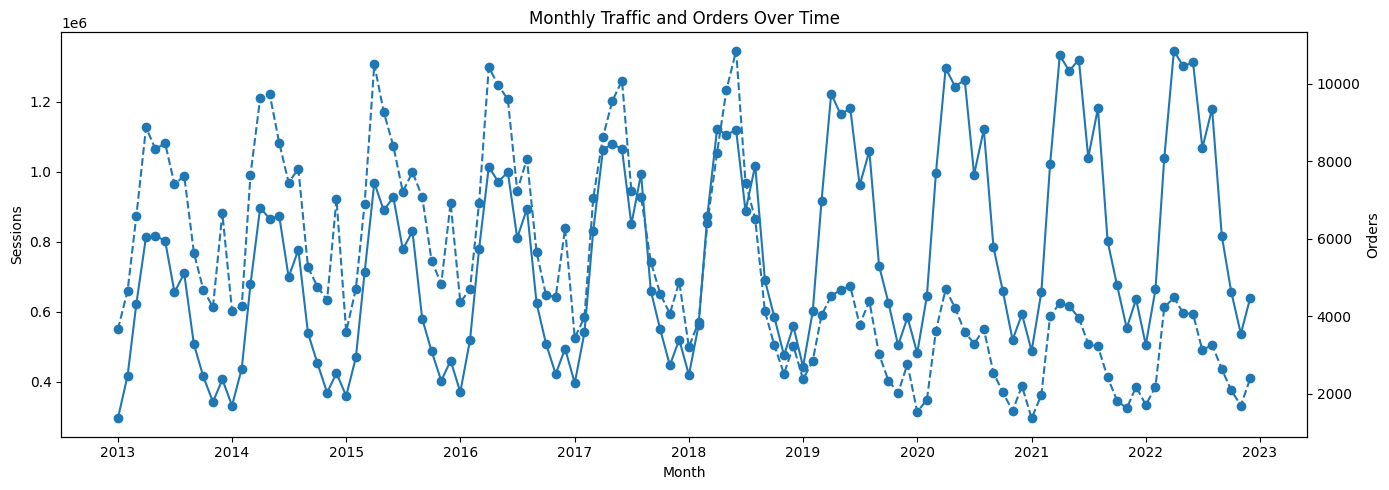

In [15]:
monthly = df_6_daily.groupby("year_month").agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    num_orders=("num_orders", "sum"),
    num_customers=("num_customers", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean")
).reset_index()

monthly["conversion_rate"] = monthly["num_orders"] / monthly["sessions"]
monthly["orders_per_1000_sessions"] = monthly["conversion_rate"] * 1000

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(monthly["year_month"], monthly["sessions"], marker="o", label="Sessions")
ax1.set_xlabel("Month")
ax1.set_ylabel("Sessions")

ax2 = ax1.twinx()
ax2.plot(monthly["year_month"], monthly["num_orders"], marker="o", linestyle="--", label="Orders")
ax2.set_ylabel("Orders")

plt.title("Monthly Traffic and Orders Over Time")
fig.tight_layout()
plt.show()

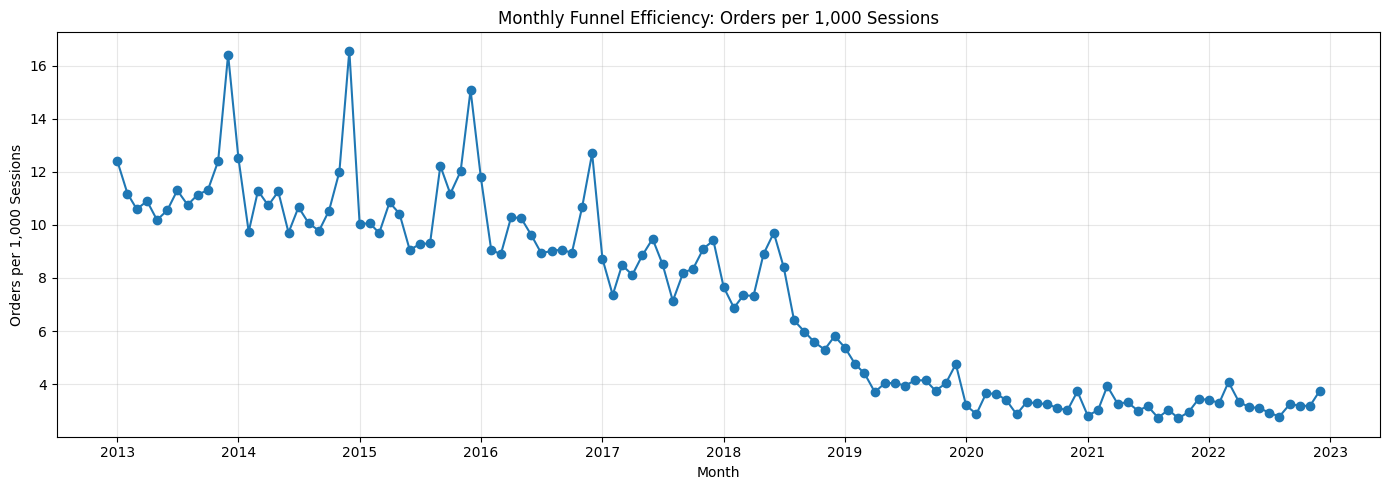

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly["year_month"],
    monthly["orders_per_1000_sessions"],
    marker="o"
)

plt.title("Monthly Funnel Efficiency: Orders per 1,000 Sessions")
plt.xlabel("Month")
plt.ylabel("Orders per 1,000 Sessions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

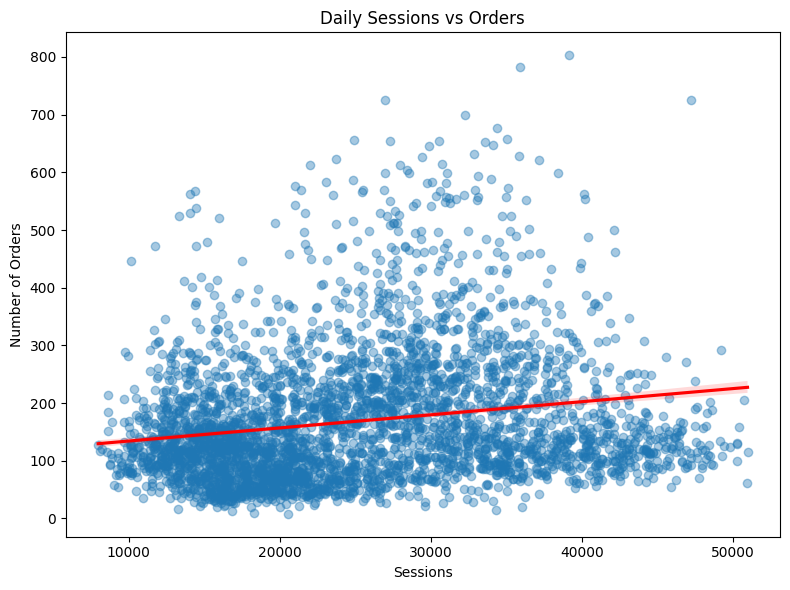

Correlation between sessions and orders: 0.1909


In [17]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_6_daily,
    x="sessions",
    y="num_orders",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Daily Sessions vs Orders")
plt.xlabel("Sessions")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

corr_sessions_orders = df_6_daily[["sessions", "num_orders"]].corr().iloc[0, 1]
print(f"Correlation between sessions and orders: {corr_sessions_orders:.4f}")

In [18]:
session_threshold = df_6_daily["sessions"].quantile(0.75)
conversion_threshold = df_6_daily["conversion_rate"].quantile(0.25)

df_6_daily["traffic_conversion_group"] = np.where(
    (df_6_daily["sessions"] >= session_threshold) &
    (df_6_daily["conversion_rate"] <= conversion_threshold),
    "High traffic, low conversion",
    "Other"
)

leakage_days = df_6_daily[df_6_daily["traffic_conversion_group"] == "High traffic, low conversion"].copy()

print("Number of high-traffic low-conversion days:", len(leakage_days))

leakage_days[[
    "date",
    "sessions",
    "num_orders",
    "conversion_rate",
    "orders_per_1000_sessions",
    "bounce_rate",
    "avg_session_duration_sec"
]].sort_values("orders_per_1000_sessions").head(20)

Number of high-traffic low-conversion days: 397


,date,sessions,num_orders,conversion_rate,orders_per_1000_sessions,bounce_rate,avg_session_duration_sec
2982,2021-03-02,34281,14,0.000408,0.408389,0.00511,194.1
2616,2020-03-01,36014,19,0.000528,0.527573,0.00375,132.7
3106,2021-07-04,32810,28,0.000853,0.853398,0.00448,297.0
2618,2020-03-03,34111,30,0.000879,0.879482,0.00469,192.6
3472,2022-07-05,32386,33,0.001019,1.018959,0.00516,111.2
2741,2020-07-04,36231,37,0.001021,1.021225,0.00358,262.5
3348,2022-03-03,33496,37,0.001105,1.104610,0.00562,281.3
2983,2021-03-03,37125,42,0.001131,1.131313,0.00415,299.1
3410,2022-05-04,45850,54,0.001178,1.177754,0.00493,262.5
3380,2022-04-04,50915,61,0.001198,1.198075,0.00543,120.6


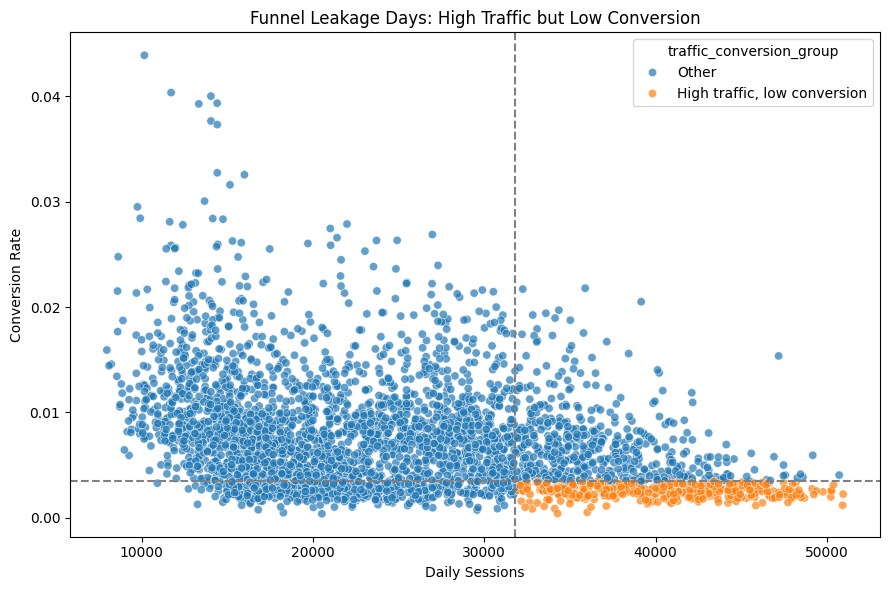

In [19]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_6_daily,
    x="sessions",
    y="conversion_rate",
    hue="traffic_conversion_group",
    alpha=0.7
)

plt.axvline(session_threshold, linestyle="--", color="gray")
plt.axhline(conversion_threshold, linestyle="--", color="gray")

plt.title("Funnel Leakage Days: High Traffic but Low Conversion")
plt.xlabel("Daily Sessions")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

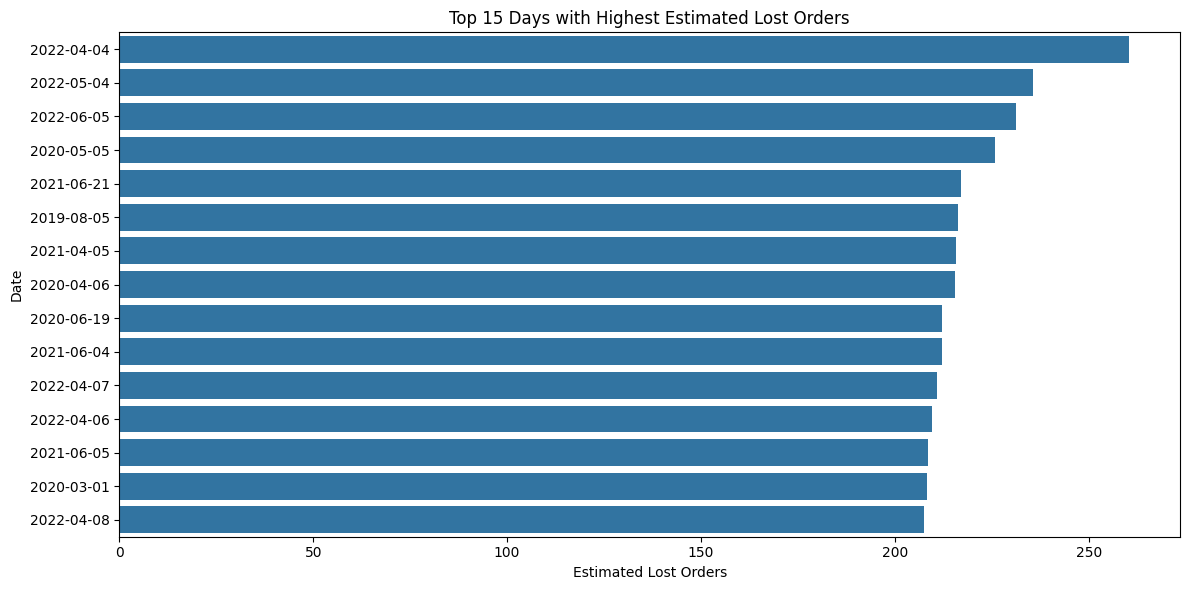

,date,sessions,num_orders,conversion_rate,orders_per_1000_sessions,lost_orders_proxy
3380,2022-04-04,50915,61,0.001198,1.198075,260.537937
3410,2022-05-04,45850,54,0.001178,1.177754,235.551496
3442,2022-06-05,47723,70,0.001467,1.466798,231.379848
2681,2020-05-05,46233,66,0.001428,1.427552,225.970214
3093,2021-06-21,50225,100,0.001991,1.991040,217.180455
2407,2019-08-05,44223,63,0.001425,1.424598,216.276681
3016,2021-04-05,47943,87,0.001815,1.814655,215.769190
2652,2020-04-06,48680,92,0.001890,1.889893,215.423486
2726,2020-06-19,48502,94,0.001938,1.938064,212.299382
3076,2021-06-04,44701,70,0.001566,1.565960,212.295342


In [20]:
benchmark_cr = df_6_daily["conversion_rate"].median()

df_6_daily["expected_orders_at_median_cr"] = df_6_daily["sessions"] * benchmark_cr
df_6_daily["lost_orders_proxy"] = (
    df_6_daily["expected_orders_at_median_cr"] - df_6_daily["num_orders"]
).clip(lower=0)

top_lost_days = df_6_daily.sort_values("lost_orders_proxy", ascending=False).head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_lost_days,
    x="lost_orders_proxy",
    y=top_lost_days["date"].dt.strftime("%Y-%m-%d")
)

plt.title("Top 15 Days with Highest Estimated Lost Orders")
plt.xlabel("Estimated Lost Orders")
plt.ylabel("Date")
plt.tight_layout()
plt.show()

top_lost_days[[
    "date",
    "sessions",
    "num_orders",
    "conversion_rate",
    "orders_per_1000_sessions",
    "lost_orders_proxy"
]]

In [21]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_perf = df_6_daily.groupby("day_of_week").agg(
    avg_sessions=("sessions", "mean"),
    avg_orders=("num_orders", "mean"),
    avg_conversion_rate=("conversion_rate", "mean"),
    avg_orders_per_1000_sessions=("orders_per_1000_sessions", "mean")
).reindex(weekday_order).reset_index()

weekday_perf

,day_of_week,avg_sessions,avg_orders,avg_conversion_rate,avg_orders_per_1000_sessions
0,Monday,25222.182342,169.460653,0.007608,7.608365
1,Tuesday,24914.773946,176.137931,0.007752,7.752216
2,Wednesday,25150.203065,184.597701,0.007848,7.848157
3,Thursday,25153.946360,176.605364,0.007505,7.504773
4,Friday,24878.863985,157.693487,0.006835,6.835446
5,Saturday,24922.662835,152.670498,0.006735,6.735490
6,Sunday,25050.105566,161.426104,0.007205,7.205129


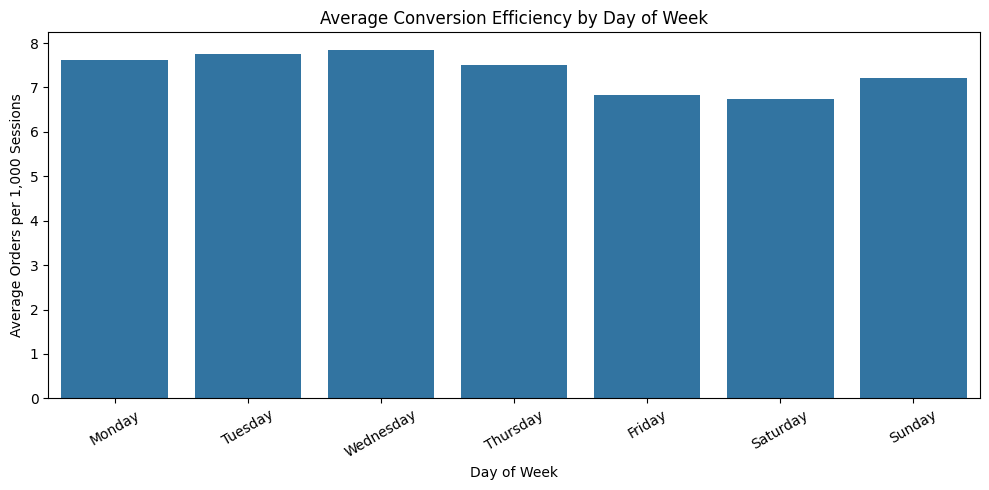

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_perf,
    x="day_of_week",
    y="avg_orders_per_1000_sessions",
    order=weekday_order
)

plt.title("Average Conversion Efficiency by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Orders per 1,000 Sessions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
weekend_perf = df_6_daily.groupby("is_weekend").agg(
    avg_sessions=("sessions", "mean"),
    avg_orders=("num_orders", "mean"),
    avg_conversion_rate=("conversion_rate", "mean"),
    avg_orders_per_1000_sessions=("orders_per_1000_sessions", "mean")
).reset_index()

weekend_perf["day_type"] = weekend_perf["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

weekend_perf

,is_weekend,avg_sessions,avg_orders,avg_conversion_rate,avg_orders_per_1000_sessions,day_type
0,0,25063.933308,172.900345,0.00751,7.509754,Weekday
1,1,24986.323106,157.044104,0.00697,6.970084,Weekend


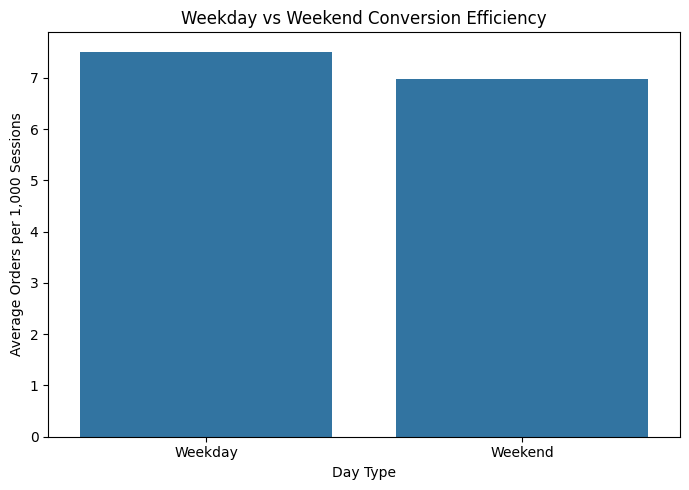

In [24]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=weekend_perf,
    x="day_type",
    y="avg_orders_per_1000_sessions"
)

plt.title("Weekday vs Weekend Conversion Efficiency")
plt.xlabel("Day Type")
plt.ylabel("Average Orders per 1,000 Sessions")
plt.tight_layout()
plt.show()

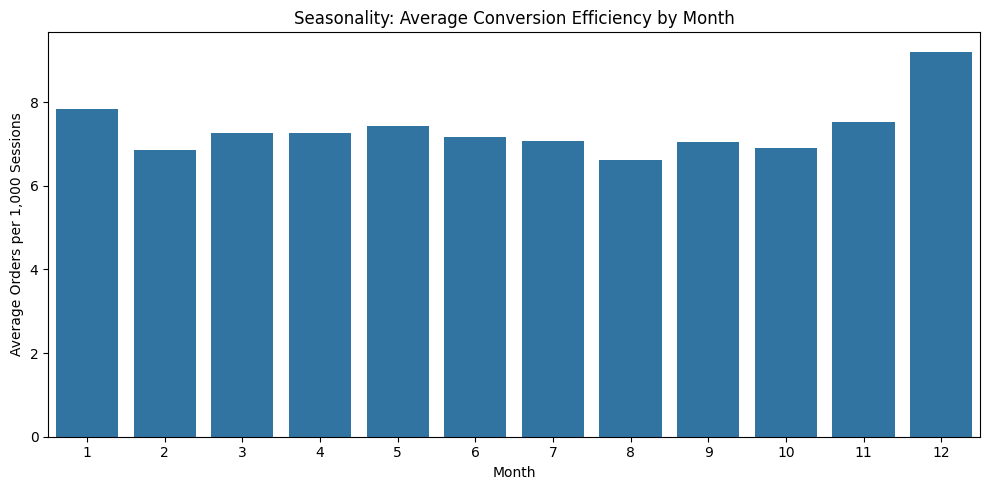

In [25]:
month_order = list(range(1, 13))

monthly_seasonality = df_6_daily.groupby("month").agg(
    avg_sessions=("sessions", "mean"),
    avg_orders=("num_orders", "mean"),
    avg_conversion_rate=("conversion_rate", "mean"),
    avg_orders_per_1000_sessions=("orders_per_1000_sessions", "mean")
).reindex(month_order).reset_index()

monthly_seasonality
plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_seasonality,
    x="month",
    y="avg_orders_per_1000_sessions"
)

plt.title("Seasonality: Average Conversion Efficiency by Month")
plt.xlabel("Month")
plt.ylabel("Average Orders per 1,000 Sessions")
plt.tight_layout()
plt.show()

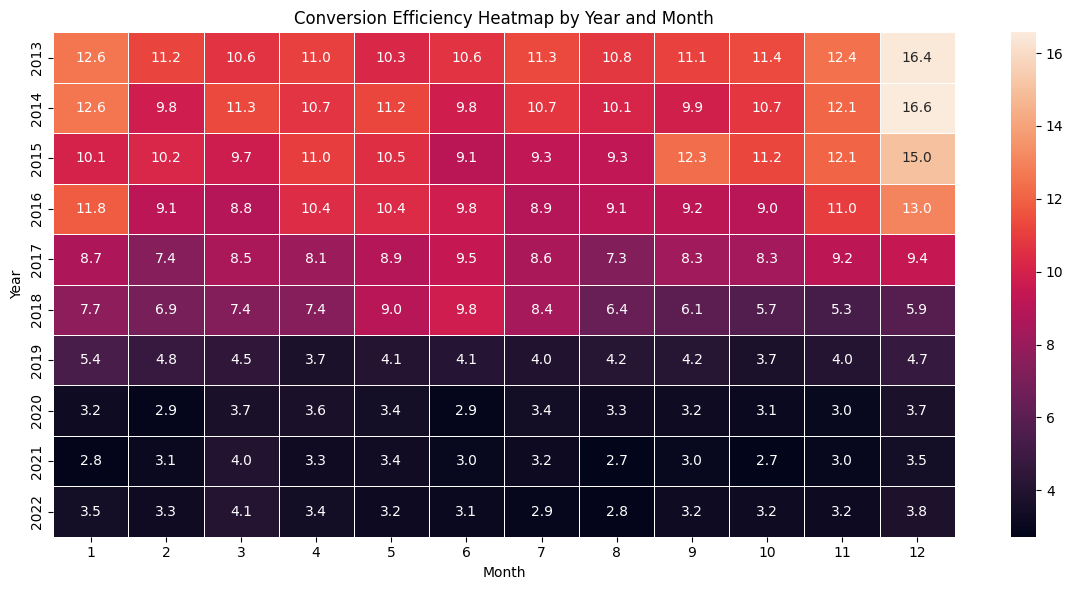

In [26]:
heatmap_data = df_6_daily.groupby(["year", "month"]).agg(
    orders_per_1000_sessions=("orders_per_1000_sessions", "mean")
).reset_index()

heatmap_pivot = heatmap_data.pivot(
    index="year",
    columns="month",
    values="orders_per_1000_sessions"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Conversion Efficiency Heatmap by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

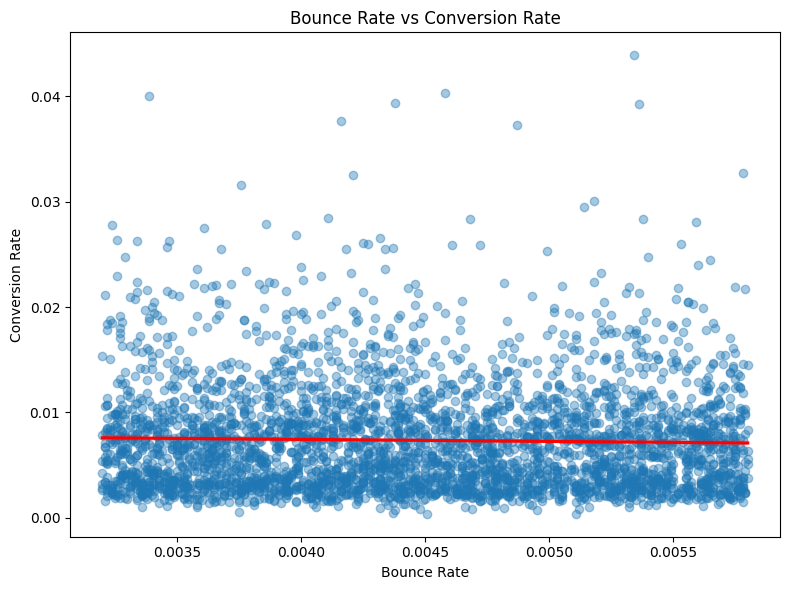

Correlation between bounce rate and conversion rate: -0.0281


In [27]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_6_daily,
    x="bounce_rate",
    y="conversion_rate",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Bounce Rate vs Conversion Rate")
plt.xlabel("Bounce Rate")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

corr_bounce_conversion = df_6_daily[["bounce_rate", "conversion_rate"]].corr().iloc[0, 1]
print(f"Correlation between bounce rate and conversion rate: {corr_bounce_conversion:.4f}")

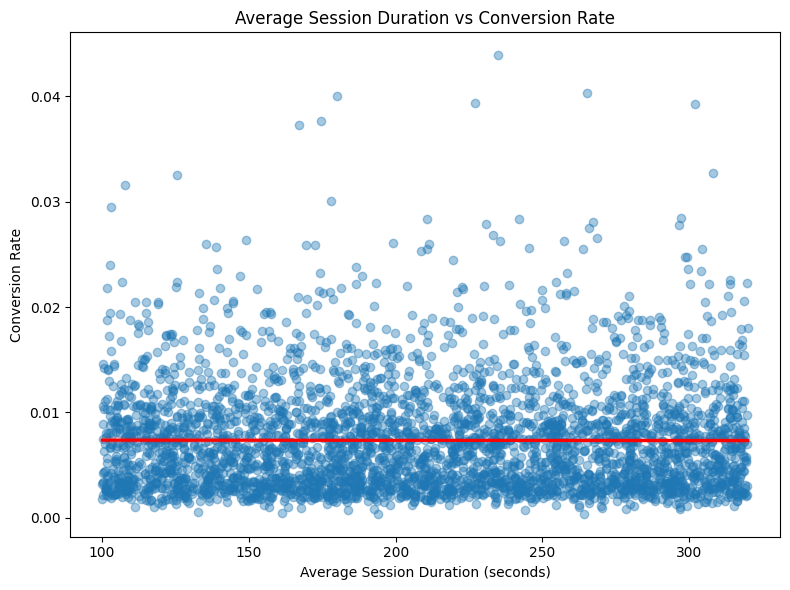

Correlation between session duration and conversion rate: -0.0023


In [28]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_6_daily,
    x="avg_session_duration_sec",
    y="conversion_rate",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Average Session Duration vs Conversion Rate")
plt.xlabel("Average Session Duration (seconds)")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

corr_duration_conversion = df_6_daily[["avg_session_duration_sec", "conversion_rate"]].corr().iloc[0, 1]
print(f"Correlation between session duration and conversion rate: {corr_duration_conversion:.4f}")

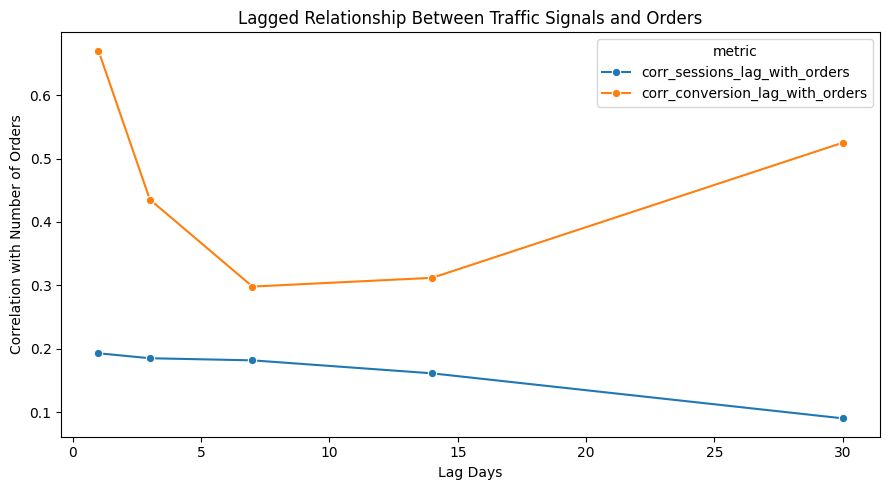

In [29]:
df_lag = df_6_daily.copy()

for lag in [1, 3, 7, 14, 30]:
    df_lag[f"sessions_lag_{lag}"] = df_lag["sessions"].shift(lag)
    df_lag[f"conversion_lag_{lag}"] = df_lag["conversion_rate"].shift(lag)

lag_corrs = []

for lag in [1, 3, 7, 14, 30]:
    corr_sessions = df_lag[[f"sessions_lag_{lag}", "num_orders"]].corr().iloc[0, 1]
    corr_conversion = df_lag[[f"conversion_lag_{lag}", "num_orders"]].corr().iloc[0, 1]

    lag_corrs.append({
        "lag_days": lag,
        "corr_sessions_lag_with_orders": corr_sessions,
        "corr_conversion_lag_with_orders": corr_conversion
    })

lag_corrs = pd.DataFrame(lag_corrs)
lag_corrs
lag_corrs_long = lag_corrs.melt(
    id_vars="lag_days",
    value_vars=[
        "corr_sessions_lag_with_orders",
        "corr_conversion_lag_with_orders"
    ],
    var_name="metric",
    value_name="correlation"
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=lag_corrs_long,
    x="lag_days",
    y="correlation",
    hue="metric",
    marker="o"
)

plt.title("Lagged Relationship Between Traffic Signals and Orders")
plt.xlabel("Lag Days")
plt.ylabel("Correlation with Number of Orders")
plt.tight_layout()
plt.show()

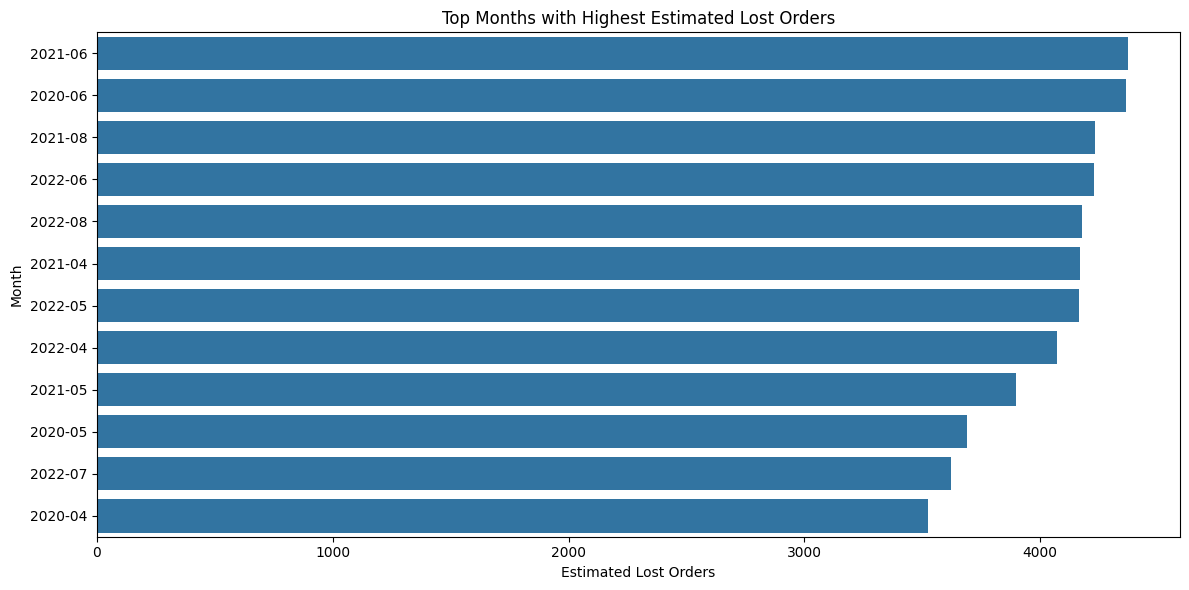

In [30]:
# Monthly leakage opportunity
monthly_opportunity = df_6_daily.groupby("year_month").agg(
    sessions=("sessions", "sum"),
    orders=("num_orders", "sum"),
    lost_orders_proxy=("lost_orders_proxy", "sum"),
    avg_conversion_rate=("conversion_rate", "mean"),
    avg_orders_per_1000_sessions=("orders_per_1000_sessions", "mean")
).reset_index()

monthly_opportunity = monthly_opportunity.sort_values("lost_orders_proxy", ascending=False)

monthly_opportunity.head(15)
plt.figure(figsize=(12, 6))

top_months = monthly_opportunity.head(12).copy()
top_months["year_month_str"] = top_months["year_month"].dt.strftime("%Y-%m")

sns.barplot(
    data=top_months,
    x="lost_orders_proxy",
    y="year_month_str"
)

plt.title("Top Months with Highest Estimated Lost Orders")
plt.xlabel("Estimated Lost Orders")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

In [31]:
overall_cr = df_6_daily["num_orders"].sum() / df_6_daily["sessions"].sum()
overall_orders_per_1000 = overall_cr * 1000

best_month = monthly.sort_values("orders_per_1000_sessions", ascending=False).iloc[0]
worst_month = monthly.sort_values("orders_per_1000_sessions", ascending=True).iloc[0]

best_weekday = weekday_perf.sort_values("avg_orders_per_1000_sessions", ascending=False).iloc[0]
worst_weekday = weekday_perf.sort_values("avg_orders_per_1000_sessions", ascending=True).iloc[0]

largest_lost_day = df_6_daily.sort_values("lost_orders_proxy", ascending=False).iloc[0]
largest_lost_month = monthly_opportunity.sort_values("lost_orders_proxy", ascending=False).iloc[0]

print("OVERALL FUNNEL PERFORMANCE")
print(f"- Overall conversion rate: {overall_cr*100:.2f}%")
print(f"- Overall orders per 1,000 sessions: {overall_orders_per_1000:.2f}")

print("\nMONTHLY PERFORMANCE")
print(f"- Best month: {best_month['year_month'].strftime('%Y-%m')} with {best_month['orders_per_1000_sessions']:.2f} orders per 1,000 sessions")
print(f"- Worst month: {worst_month['year_month'].strftime('%Y-%m')} with {worst_month['orders_per_1000_sessions']:.2f} orders per 1,000 sessions")

print("\nWEEKDAY PERFORMANCE")
print(f"- Best weekday: {best_weekday['day_of_week']} with {best_weekday['avg_orders_per_1000_sessions']:.2f} orders per 1,000 sessions")
print(f"- Worst weekday: {worst_weekday['day_of_week']} with {worst_weekday['avg_orders_per_1000_sessions']:.2f} orders per 1,000 sessions")

print("\nLOST ORDER OPPORTUNITY")
print(f"- Largest lost-order day: {largest_lost_day['date'].strftime('%Y-%m-%d')} with estimated lost orders of {largest_lost_day['lost_orders_proxy']:.0f}")
print(f"- Largest lost-order month: {largest_lost_month['year_month'].strftime('%Y-%m')} with estimated lost orders of {largest_lost_month['lost_orders_proxy']:.0f}")

OVERALL FUNNEL PERFORMANCE
- Overall conversion rate: 0.67%
- Overall orders per 1,000 sessions: 6.72

MONTHLY PERFORMANCE
- Best month: 2014-12 with 16.56 orders per 1,000 sessions
- Worst month: 2021-10 with 2.71 orders per 1,000 sessions

WEEKDAY PERFORMANCE
- Best weekday: Wednesday with 7.85 orders per 1,000 sessions
- Worst weekday: Saturday with 6.74 orders per 1,000 sessions

LOST ORDER OPPORTUNITY
- Largest lost-order day: 2022-04-04 with estimated lost orders of 261
- Largest lost-order month: 2021-06 with estimated lost orders of 4374
